# Plotting with unstack()

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
plt.style.use('ggplot')

In [45]:
titanic = pd.read_csv('../../../data/titanic.csv')

In [46]:
titanic.set_index(['pclass', 'sex'], inplace=True)

In [47]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1309 entries, (np.int64(1), 'female') to (np.int64(3), 'male')
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   survived   1309 non-null   int64 
 1   name       1309 non-null   object
 2   age        1309 non-null   object
 3   sibsp      1309 non-null   int64 
 4   parch      1309 non-null   int64 
 5   ticket     1309 non-null   object
 6   fare       1309 non-null   object
 7   cabin      1309 non-null   object
 8   embarked   1309 non-null   object
 9   boat       1309 non-null   object
 10  body       1309 non-null   object
 11  home.dest  1309 non-null   object
dtypes: int64(3), object(9)
memory usage: 125.6+ KB


In [48]:
titanic['age'] = pd.to_numeric(titanic['age'], errors='coerce').fillna(0)

In [49]:
titanic.groupby(['pclass', 'sex'])['age'].mean()

pclass  sex   
1       female    34.208333
        male      34.611266
2       female    26.720912
        male      28.472709
3       female    15.611883
        male      18.378972
Name: age, dtype: float64

<Axes: xlabel='pclass,sex'>

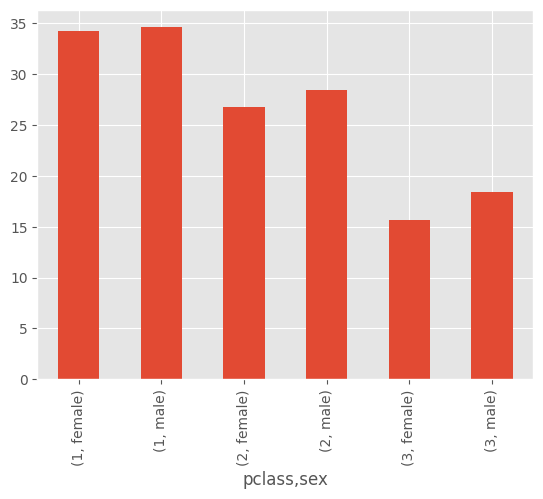

In [50]:
titanic.groupby(['pclass', 'sex'])['age'].mean().plot(kind='bar')

# Now we will use unstack() for clear plot

In [51]:
titanic.groupby(['pclass', 'sex'])['age'].mean().unstack()

sex,female,male
pclass,,
1,34.208333,34.611266
2,26.720912,28.472709
3,15.611883,18.378972


<Axes: xlabel='pclass'>

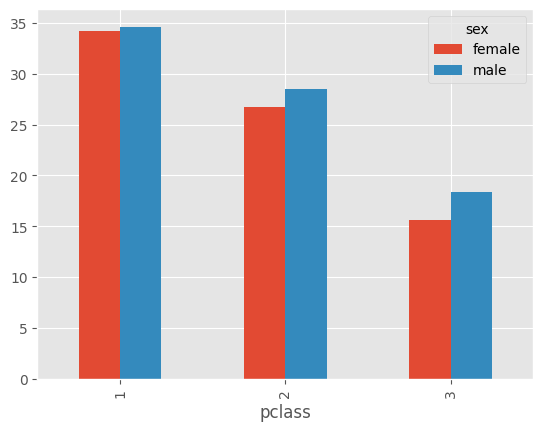

In [52]:
titanic.groupby(['pclass', 'sex'])['age'].mean().unstack().plot(kind = 'bar')

In [53]:
titanic.groupby(['pclass', 'sex'])['age'].mean().unstack(level='pclass')

pclass,1,2,3
sex,,,
female,34.208333,26.720912,15.611883
male,34.611266,28.472709,18.378972


<Axes: xlabel='sex'>

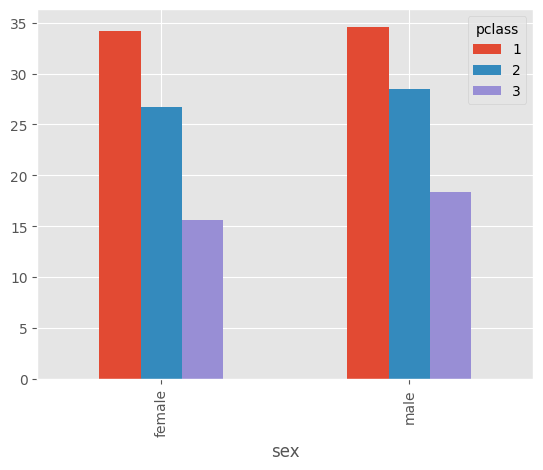

In [54]:
titanic.groupby(['pclass', 'sex'])['age'].mean().unstack(level='pclass').plot(kind='bar')

In [55]:
titanic.groupby(['sex', 'survived']).mean(numeric_only='True')

age     sibsp     parch
sex    survived                               
female 0         19.090551  1.031496  0.889764
       1         25.681662  0.510324  0.536873
male   0         24.168744  0.426686  0.224340
       1         22.621118  0.360248  0.347826

In [56]:
titanic.groupby(['sex', 'survived']).mean(numeric_only='True').unstack()

age                sibsp               parch          
survived          0          1         0         1         0         1
sex                                                                   
female    19.090551  25.681662  1.031496  0.510324  0.889764  0.536873
male      24.168744  22.621118  0.426686  0.360248  0.224340  0.347826

<Axes: xlabel='sex'>

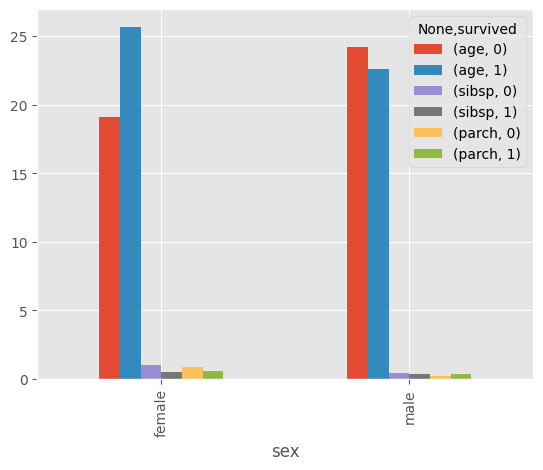

In [57]:
titanic.groupby(['sex', 'survived']).mean(numeric_only='True').unstack().plot(kind='bar')

<Axes: xlabel='survived'>

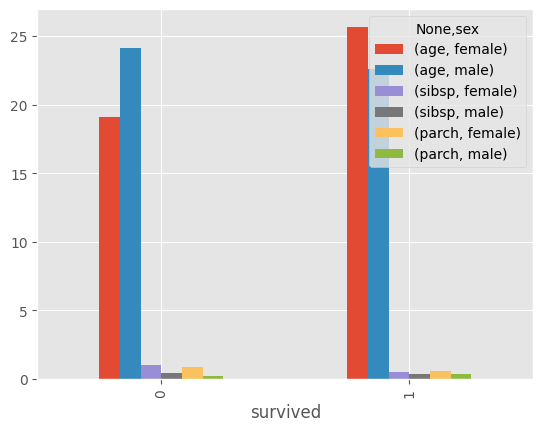

In [60]:
titanic.groupby(['sex', 'survived']).mean(numeric_only='True').unstack(level='sex').plot(kind='bar')